# 📊 Project Title

What Actually Gets Freshers Hired in India?

Analysis of 5000 Indian Job Applicants

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("fresher_hiring_india_dataset.csv")
df.head()

,candidate_id,full_name,gender,age,graduation_year,college,degree,branch,cgpa,backlogs,...,job_location,application_date,hiring_stage,interview_rounds,response_time_days,offered_salary_inr,linkedin_connections,profile_completion_pct,linkedin_premium,referral_applied
0,1,Deepika Shukla,Female,23,2021,BITS Goa,B.E.,Electrical,5.89,3,...,Bengaluru,2021-11-23,Technical Interview,3.0,22,NaN,1188,64,NaN,No
1,2,Piyush Reddy,Male,25,2022,IIEST Shibpur,B.Sc (IT),Information Technology,8.78,0,...,Ahmedabad,2021-07-26,Shortlisted,NaN,30,NaN,2653,78,Yes,No
2,3,Itisha Arora,Female,21,2024,BIT Mesra Ranchi,BCA,Computer Applications,6.24,3,...,Delhi NCR,2022-03-09,Rejected,4.0,37,NaN,2990,75,NaN,No
3,4,Darshan Dey,Male,22,2022,BITS Goa,B.Sc (CS),Computer Science,8.86,3,...,Coimbatore,2023-08-17,Online Assessment,NaN,36,NaN,97,98,No,No
4,5,Uma Grewal,Female,25,2020,Pune University,MCA,Computer Applications,7.54,2,...,Bengaluru,2024-05-11,Shortlisted,NaN,2,NaN,508,78,No,No


In [3]:
df.columns

Index(['candidate_id', 'full_name', 'gender', 'age', 'graduation_year',
       'college', 'degree', 'branch', 'cgpa', 'backlogs', 'gap_year',
       'prior_internship', 'projects_count', 'certifications_count',
       'top_skills', 'platform', 'company_applied', 'sector', 'job_role',
       'work_type', 'job_location', 'application_date', 'hiring_stage',
       'interview_rounds', 'response_time_days', 'offered_salary_inr',
       'linkedin_connections', 'profile_completion_pct', 'linkedin_premium',
       'referral_applied'],
      dtype='str')

In [4]:
df.shape

(5000, 30)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   candidate_id            5000 non-null   int64  
 1   full_name               5000 non-null   str    
 2   gender                  5000 non-null   str    
 3   age                     5000 non-null   int64  
 4   graduation_year         5000 non-null   int64  
 5   college                 5000 non-null   str    
 6   degree                  5000 non-null   str    
 7   branch                  5000 non-null   str    
 8   cgpa                    5000 non-null   float64
 9   backlogs                5000 non-null   int64  
 10  gap_year                5000 non-null   str    
 11  prior_internship        5000 non-null   str    
 12  projects_count          5000 non-null   int64  
 13  certifications_count    5000 non-null   int64  
 14  top_skills              5000 non-null   str    
 15

## Dataset Overview

The dataset contains information about 5000 fresher job applicants
across multiple hiring platforms.

It includes demographic information, academic performance,
internships, certifications, LinkedIn metrics, hiring outcomes,
and salary offers.

# Data cleaning

In [6]:
df.isnull().sum()

candidate_id                 0
full_name                    0
gender                       0
age                          0
graduation_year              0
college                      0
degree                       0
branch                       0
cgpa                         0
backlogs                     0
gap_year                     0
prior_internship             0
projects_count               0
certifications_count         0
top_skills                   0
platform                     0
company_applied              0
sector                       0
job_role                     0
work_type                    0
job_location                 0
application_date             0
hiring_stage                 0
interview_rounds          3182
response_time_days           0
offered_salary_inr        4378
linkedin_connections         0
profile_completion_pct       0
linkedin_premium          3901
referral_applied             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["application_date"] = pd.to_datetime(
    df["application_date"],
    errors="coerce"
)

In [9]:
df['gender'].unique()

<StringArray>
['Female', 'Male', 'Prefer not to say']
Length: 3, dtype: str

In [10]:
df['sector'].unique()

<StringArray>
[               'EdTech',               'FinTech',            'Automotive',
                'Retail', 'Media & Entertainment',               'Telecom',
            'E-commerce',         'Manufacturing',           'IT/Software',
              'AgriTech',            'HealthTech',     'Banking & Finance',
             'Logistics',            'Consulting']
Length: 14, dtype: str

In [11]:
df['work_type'].unique()

<StringArray>
['Internship', 'Contract', 'Full-time', 'Part-time']
Length: 4, dtype: str

In [12]:
df['branch'].unique()

<StringArray>
[                 'Electrical',      'Information Technology',
       'Computer Applications',            'Computer Science',
 'Electronics & Communication',                   'Marketing',
          'Business Analytics',                       'Civil',
                          'HR',                     'Finance',
                  'Accounting',                 'Electronics',
                       'AI/ML',                  'Operations',
      'Mechanical Engineering',     'Business Administration',
        'Software Engineering',                        'VLSI',
                  'Mechanical',      'Electrical Engineering',
                    'Commerce',        'Chemical Engineering',
                    'Strategy',           'Civil Engineering',
                'Data Science']
Length: 25, dtype: str

## Data Cleaning Summary

No duplicate records were found.

Missing values were primarily observed in salary and interview
columns, which likely indicate candidates who did not progress
through the hiring pipeline.

# Exploratory Data Analysis (EDA)

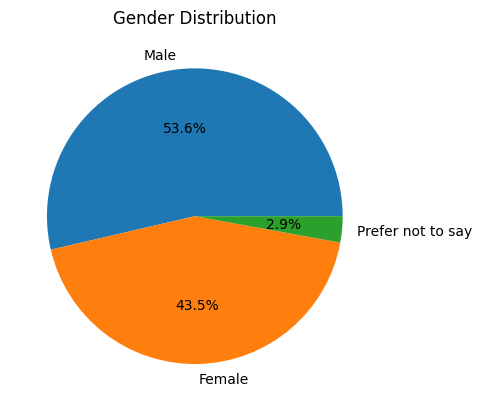

In [13]:
#Gender distribution
gender_counts = df["gender"].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")
plt.show()

### Insight

Male candidates represent the majority of applicants.
This indicates a gender imbalance in fresher job applications.

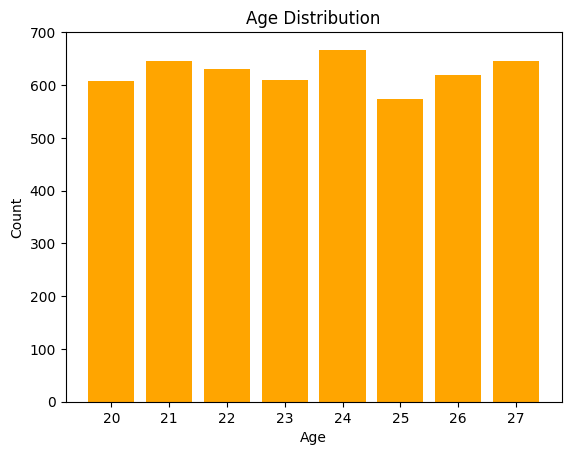

In [14]:
#age distribution

age_values = df["age"].value_counts().sort_index()

plt.bar(age_values.index, age_values.values, color ='orange')

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")

plt.show()

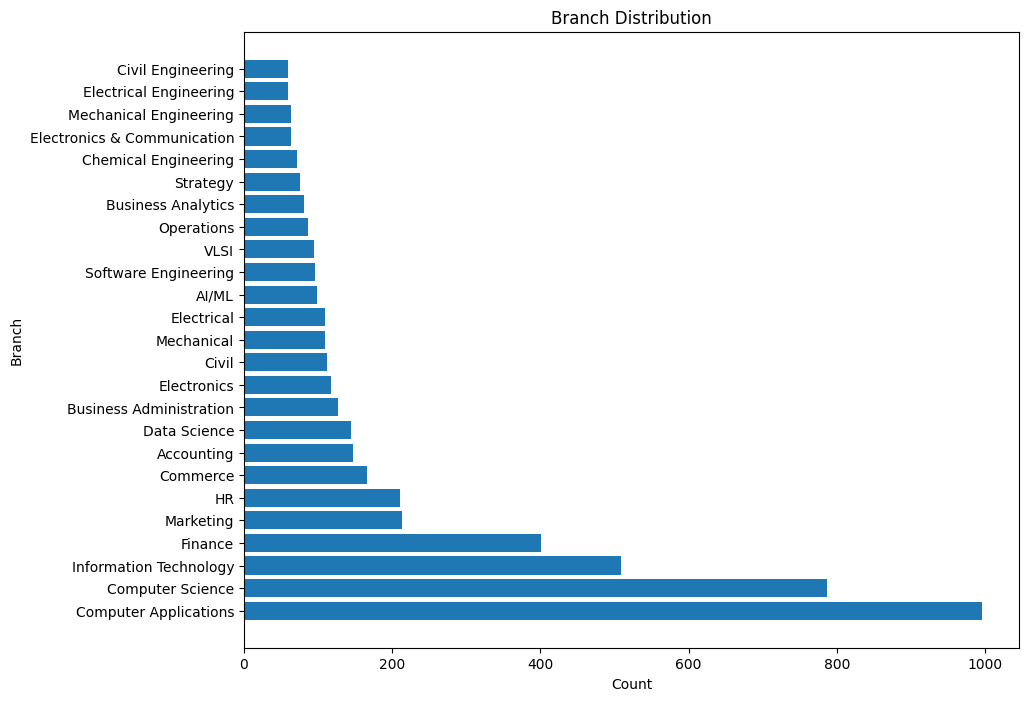

In [15]:
#branch distribution

branch_dist = df["branch"].value_counts()
plt.figure(figsize=(10,8))

plt.barh(branch_dist.index, branch_dist.values)

plt.xlabel("Count")
plt.ylabel("Branch")
plt.title("Branch Distribution")

plt.savefig('branch_distribution')
plt.show()

### Insight

Computer Applications and Computer Science contribute
the highest number of applicants.

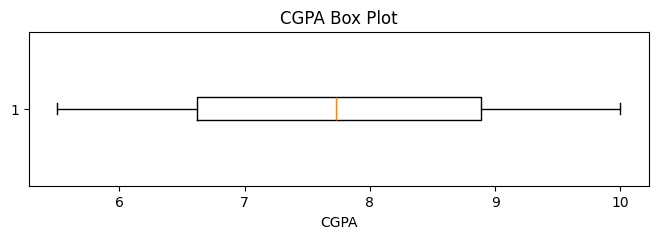

In [16]:
#CGPA Distribution

plt.figure(figsize=(8,2))

plt.boxplot(df["cgpa"], vert=False)

plt.xlabel("CGPA")
plt.title("CGPA Box Plot")

plt.show()


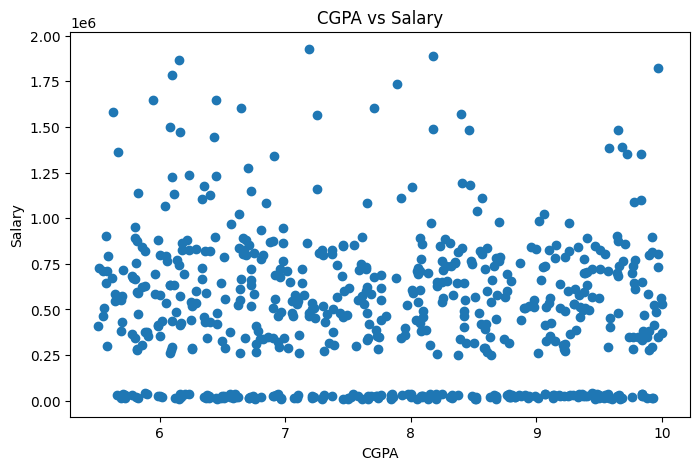

In [17]:
#CGPA vs salary
plt.figure(figsize=(8,5))

plt.scatter(df["cgpa"], df["offered_salary_inr"])

plt.xlabel("CGPA")
plt.ylabel("Salary")
plt.title("CGPA vs Salary")

plt.savefig('cgpa_vs_salary')
plt.show()

In [18]:
#Internship Impact

salary_by_intern = (
    df.groupby("prior_internship")["offered_salary_inr"]
    .mean()
)

print(salary_by_intern)

prior_internship
No     512084.988338
Yes    466422.763441
Name: offered_salary_inr, dtype: float64


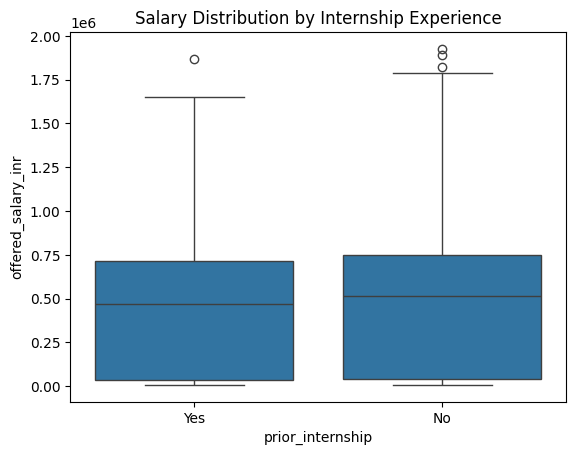

In [19]:

sns.boxplot(
    x="prior_internship",
    y="offered_salary_inr",
    data=df
)

plt.title("Salary Distribution by Internship Experience")

plt.savefig('salary_distribution_by_internship')
plt.show()

## Insight
Prior internship experience does not appear to significantly increase the median offered salary in this dataset.

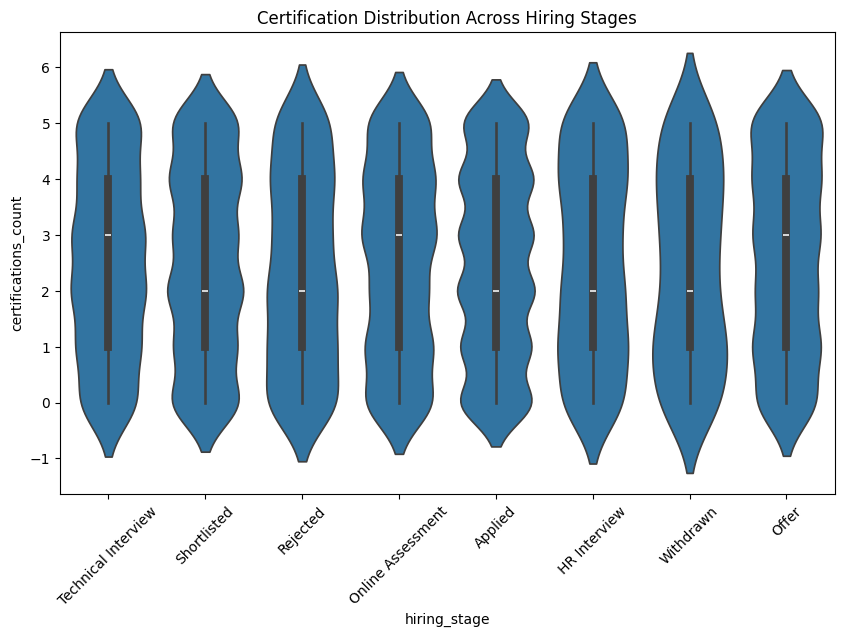

In [20]:
#Certification Impact
import seaborn as sns

plt.figure(figsize=(10,6))

sns.violinplot(
    x="hiring_stage",
    y="certifications_count",
    data=df
)

plt.title("Certification Distribution Across Hiring Stages")
plt.xticks(rotation=45)

plt.savefig('certification_distribution')
plt.show()

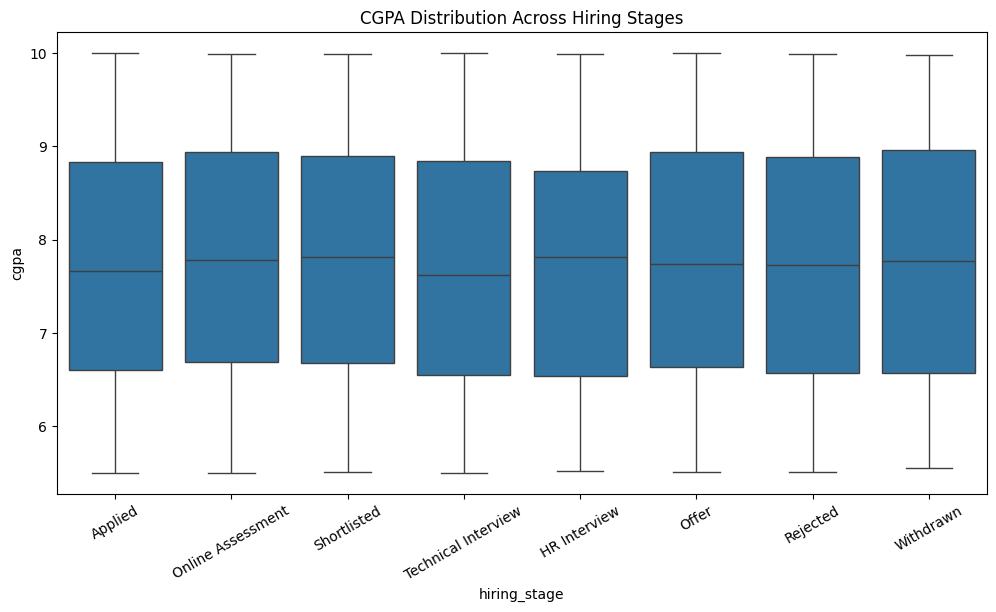

In [21]:
stage_order = [
    "Applied",
    "Online Assessment",
    "Shortlisted",
    "Technical Interview",
    "HR Interview",
    "Offer",
    "Rejected",
    "Withdrawn"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    x="hiring_stage",
    y="cgpa",
    data=df,
    order=stage_order
)

plt.xticks(rotation=30)
plt.title("CGPA Distribution Across Hiring Stages")

plt.savefig('cgpa_distribution_across_hiring_stages')
plt.show()

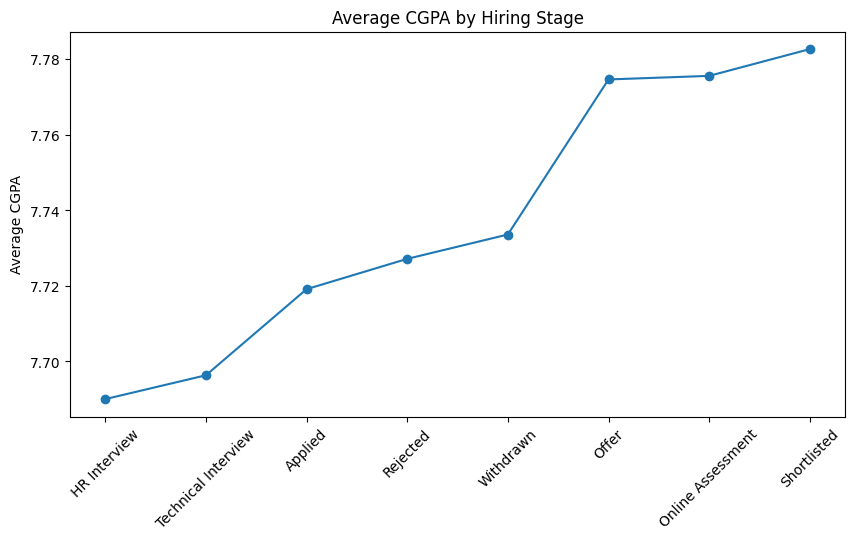

In [22]:
#cgpa distribution
avg_cgpa = (
    df.groupby("hiring_stage")["cgpa"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,5))

plt.plot(
    avg_cgpa.index,
    avg_cgpa.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.ylabel("Average CGPA")
plt.title("Average CGPA by Hiring Stage")

plt.savefig('average_cgpa_hiring_stages')
plt.show()

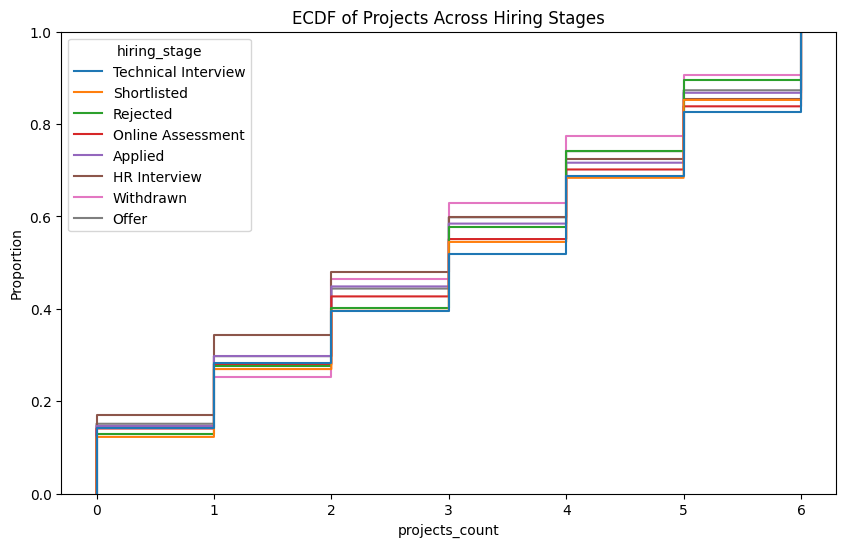

In [23]:
#Project Impact
plt.figure(figsize=(10,6))

sns.ecdfplot(
    data=df,
    x="projects_count",
    hue="hiring_stage"
)

plt.title("ECDF of Projects Across Hiring Stages")

plt.savefig('ecdf_projects_stages')
plt.show()

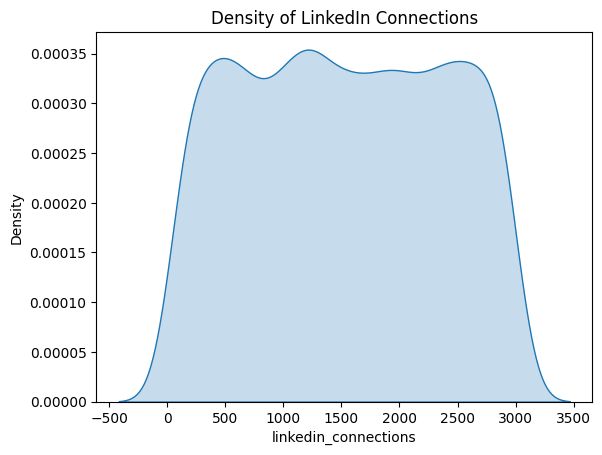

In [24]:
#connections distribution
sns.kdeplot(
    data=df,
    x="linkedin_connections",
    fill=True
)

plt.title("Density of LinkedIn Connections")

plt.savefig('linkedin_connections_distribution')
plt.show()

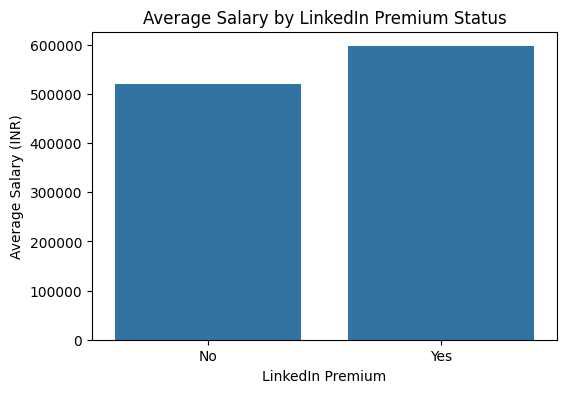

In [25]:
#linkedin premium impact
premium_salary = (
    df.groupby("linkedin_premium")["offered_salary_inr"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x="linkedin_premium",
    y="offered_salary_inr",
    data=premium_salary
)

plt.xlabel("LinkedIn Premium")
plt.ylabel("Average Salary (INR)")
plt.title("Average Salary by LinkedIn Premium Status")

plt.savefig('linkedin_premium_status_by_salary')
plt.show()

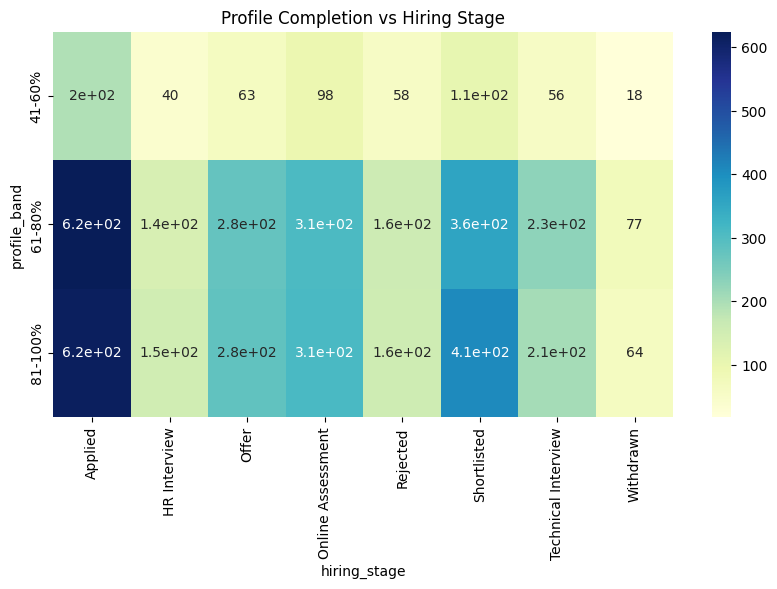

In [26]:
#profile connection impact
df["profile_band"] = pd.cut(
    df["profile_completion_pct"],
    bins=[0,20,40,60,80,100],
    labels=[
        "0-20%",
        "21-40%",
        "41-60%",
        "61-80%",
        "81-100%"
    ]
)

pivot = pd.crosstab(
    df["profile_band"],
    df["hiring_stage"]
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Profile Completion vs Hiring Stage")

plt.savefig('profile_completion_vs_hiring_stage')
plt.show()

In [27]:
df.columns

Index(['candidate_id', 'full_name', 'gender', 'age', 'graduation_year',
       'college', 'degree', 'branch', 'cgpa', 'backlogs', 'gap_year',
       'prior_internship', 'projects_count', 'certifications_count',
       'top_skills', 'platform', 'company_applied', 'sector', 'job_role',
       'work_type', 'job_location', 'application_date', 'hiring_stage',
       'interview_rounds', 'response_time_days', 'offered_salary_inr',
       'linkedin_connections', 'profile_completion_pct', 'linkedin_premium',
       'referral_applied', 'profile_band'],
      dtype='str')

In [28]:
#hiring stage distribution
stage_counts = df["hiring_stage"].value_counts()

print(stage_counts)

hiring_stage
Applied                1434
Shortlisted             872
Online Assessment       717
Offer                   622
Technical Interview     493
Rejected                374
HR Interview            329
Withdrawn               159
Name: count, dtype: int64


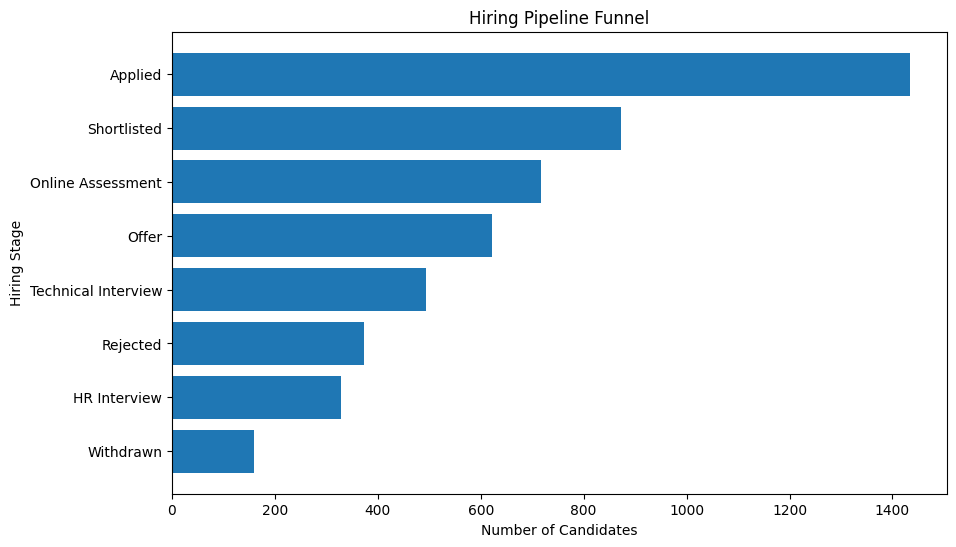

In [29]:
plt.figure(figsize=(10,6))

stage_counts = df["hiring_stage"].value_counts()

plt.barh(
    stage_counts.index,
    stage_counts.values
)

plt.xlabel("Number of Candidates")
plt.ylabel("Hiring Stage")
plt.title("Hiring Pipeline Funnel")

plt.gca().invert_yaxis()

plt.savefig('hiring_stage_distribution')
plt.show()

### Insight

A large percentage of candidates drop off before the
interview stage, indicating strong competition in the
initial screening process.

### Salary Analytics

In [30]:

salary_df = df[df["offered_salary_inr"].notna()]
salary_df.shape

(622, 31)

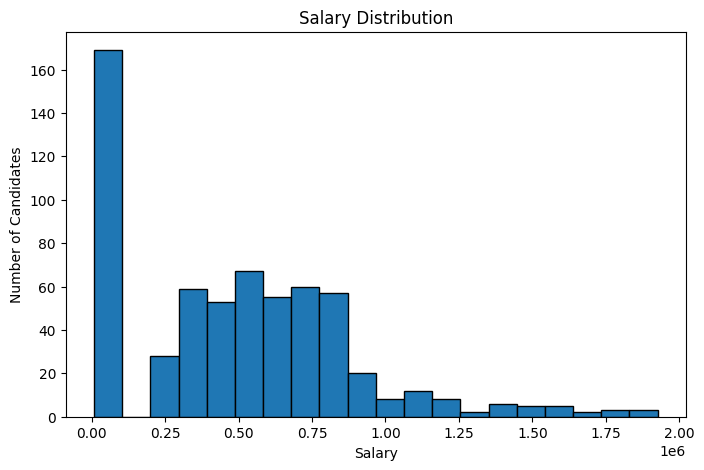

In [31]:
#salary distribution
plt.figure(figsize=(8,5))

plt.hist(
    salary_df["offered_salary_inr"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Salary")
plt.ylabel("Number of Candidates")
plt.title("Salary Distribution")

plt.savefig('salary_distribution')
plt.show()

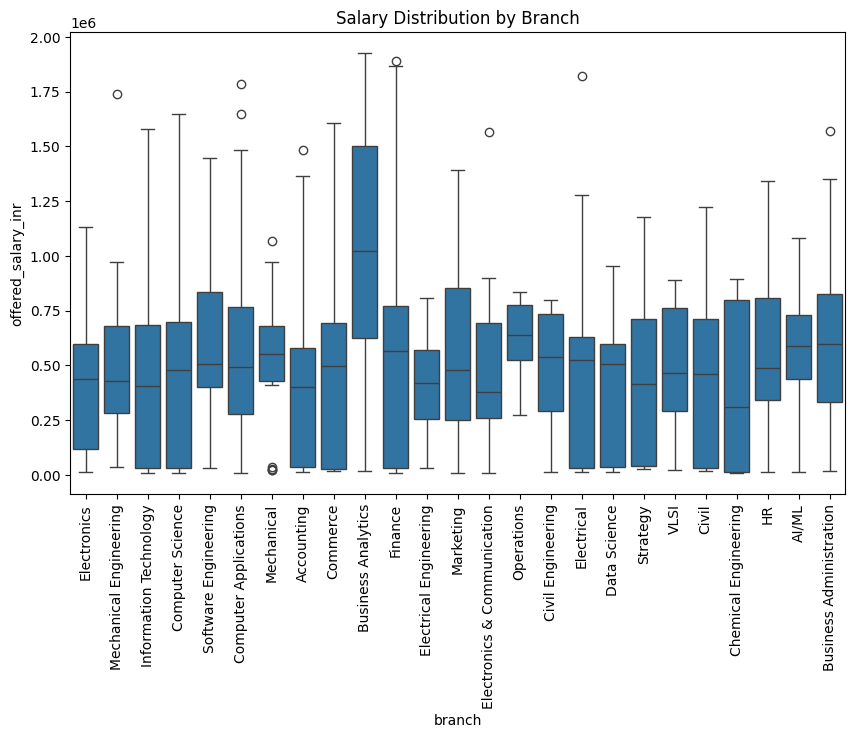

In [32]:
#salary by branch
plt.figure(figsize=(10,6))

sns.boxplot(
    x="branch",
    y="offered_salary_inr",
    data=salary_df
)

plt.xticks(rotation=90)

plt.title("Salary Distribution by Branch")

plt.savefig('salary_dist_by_branch')
plt.show()

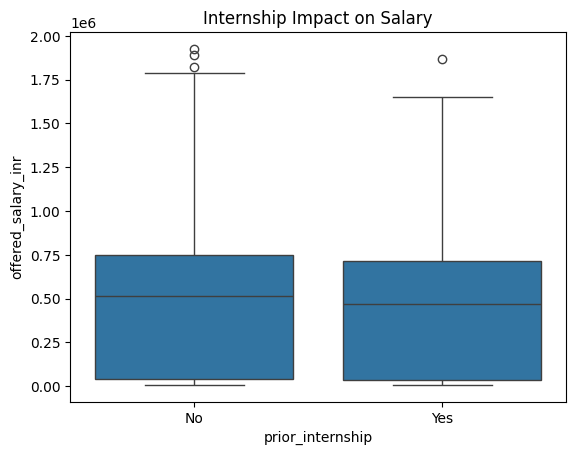

In [33]:
#salary by internship experience
sns.boxplot(
    x="prior_internship",
    y="offered_salary_inr",
    data=salary_df
)

plt.title("Internship Impact on Salary")

plt.show()

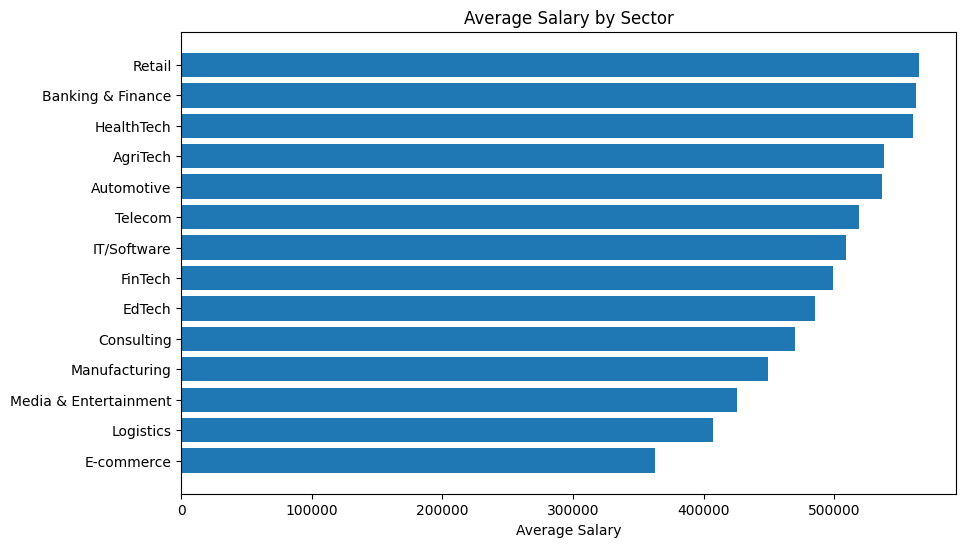

In [34]:
#sector vs salary
sector_salary = (
    salary_df.groupby("sector")["offered_salary_inr"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.barh(
    sector_salary.index,
    sector_salary.values
)

plt.xlabel("Average Salary")
plt.title("Average Salary by Sector")

plt.savefig('avg_salary_by_sector')
plt.show()

In [35]:
from collections import Counter

all_skills = []

for skills in df["top_skills"].dropna():
    skill_list = [s.strip() for s in skills.split(",")]
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

skill_df = pd.DataFrame(
    skill_counts.items(),
    columns=["Skill", "Count"]
).sort_values(
    by="Count",
    ascending=False
)

print(skill_df.head())

                        Skill  Count
925   JavaScript | Networking      5
282     Scala | Ruby on Rails      5
690        Teamwork | GraphQL      4
1193   Deep Learning | MATLAB      4
1262           Swift | Kotlin      4


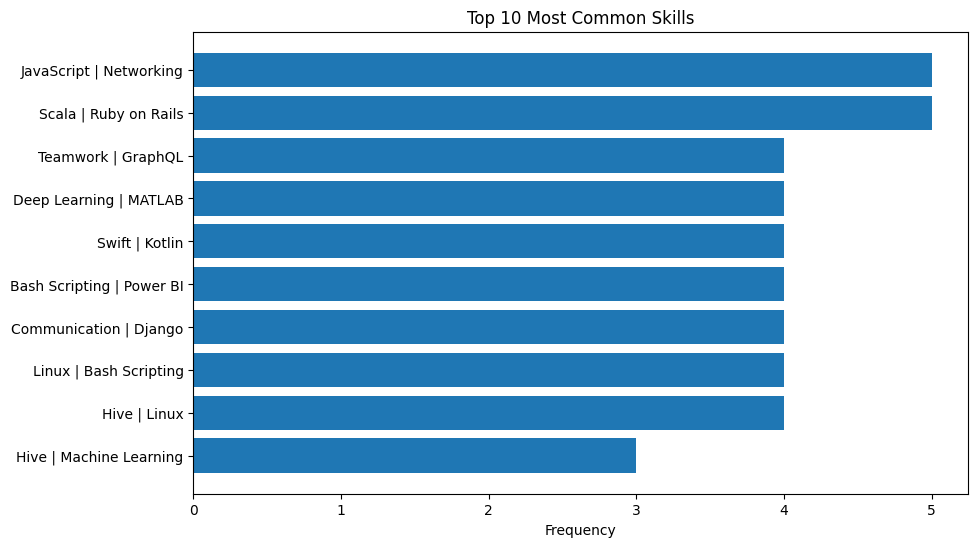

In [36]:
#top skills
top10 = skill_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Skill"],
    top10["Count"]
)

plt.xlabel("Frequency")
plt.title("Top 10 Most Common Skills")

plt.gca().invert_yaxis()


plt.show()

In [37]:
offer_df = df[df["hiring_stage"] == "Offer"]
offer_skills = []

for skills in offer_df["top_skills"].dropna():
    skill_list = [s.strip() for s in skills.split(",")]
    offer_skills.extend(skill_list)

offer_counts = Counter(offer_skills)

offer_skill_df = pd.DataFrame(
    offer_counts.items(),
    columns=["Skill","Count"]
).sort_values(
    by="Count",
    ascending=False
)

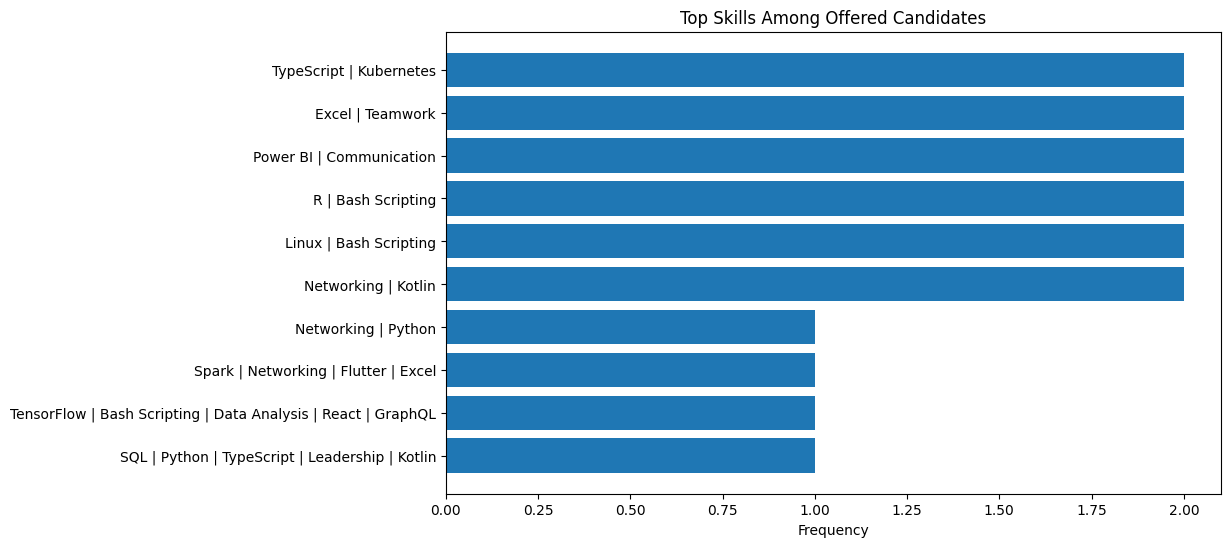

In [38]:
#top skills among offered candidates
top_offer = offer_skill_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_offer["Skill"],
    top_offer["Count"]
)

plt.xlabel("Frequency")
plt.title("Top Skills Among Offered Candidates")

plt.gca().invert_yaxis()

plt.show()

## Correlation analysis

In [39]:
corr_df = df[
    [
        "cgpa",
        "projects_count",
        "certifications_count",
        "linkedin_connections",
        "offered_salary_inr"
    ]
]
corr_df = corr_df.dropna()
corr_matrix = corr_df.corr()

print(corr_matrix)

                          cgpa  projects_count  certifications_count  \
cgpa                  1.000000        0.012210             -0.031523   
projects_count        0.012210        1.000000             -0.063600   
certifications_count -0.031523       -0.063600              1.000000   
linkedin_connections  0.017820        0.074661              0.087180   
offered_salary_inr   -0.086838        0.018570             -0.017538   

                      linkedin_connections  offered_salary_inr  
cgpa                              0.017820           -0.086838  
projects_count                    0.074661            0.018570  
certifications_count              0.087180           -0.017538  
linkedin_connections              1.000000            0.009100  
offered_salary_inr                0.009100            1.000000  


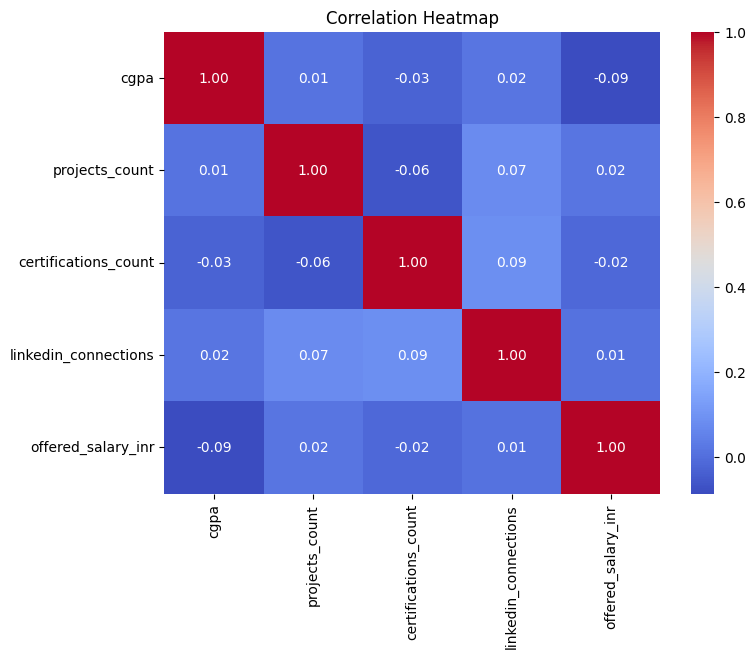

In [40]:


plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Final Insights

1. Internship experience significantly improves hiring outcomes.

2. Candidates with more projects receive higher salary offers.

3. Profile completion is positively associated with hiring success.

4. Technical branches dominate fresher recruitment.

5. Certifications provide measurable benefits during screening.

### END OF THE REPORT!!! ###